# Training a Foreground Segmentation Tool with DINOv3



### Setup

Let's start by loading some pre-requisites and checking the DINOv3 repository location:

In [5]:
# @title 1. Install Dependencies & Imports
!pip install -q roboflow torch torchvision tqdm matplotlib scikit-learn wandb torchmetrics

import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel
from google.colab import userdata, drive
from tqdm.notebook import tqdm
import random

print(" All dependencies installed and imported!")

 All dependencies installed and imported!


In [6]:
# @title 2. Mount Google Drive & Setup Paths
from google.colab import drive
import os

drive.mount('/content/drive')
print("✅ Google Drive mounted!")

# Define save paths for model weights
SAVED_WEIGHTS_PATH = '/content/drive/MyDrive/seg_head_weights.pth'
LOCAL_WEIGHTS_PATH = './seg_head_weights_local.pth'

# Create checkpoint directory (Updated to DINOv3)
checkpoint_dir = "/content/drive/MyDrive/DINOv3_Checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"Checkpoint directory: {checkpoint_dir}")

# Define Dataset Path directly to your EOR-Database folder
DATASET_PATH = '/content/drive/MyDrive/EOR-Database-MOT.v5-mot-rect-5-super-repairs-streched.coco-segmentation'
print(f"Dataset path set to: {DATASET_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted!
Checkpoint directory: /content/drive/MyDrive/DINOv3_Checkpoints
Dataset path set to: /content/drive/MyDrive/EOR-Database-MOT.v5-mot-rect-5-super-repairs-streched.coco-segmentation


In [7]:
# @title 2.5 Weights & Biases Setup with Secret Key
import wandb

# Initialize wandb (optional - you can skip if you don't want wandb)
USE_WANDB = True  # Set to False if you don't want wandb logging
wandb_run = None

if USE_WANDB:
    try:
        # Get wandb API key from Colab secrets
        wandb_api_key = userdata.get('WANDB_API')
        wandb.login(key=wandb_api_key)
        print(" WandB API key retrieved and logged in!")

        # Start a new run
        wandb.init(
            project="dino-foreground-segmentation",
            name="tao-dataset-training",
            config={
                "learning_rate": 1e-3,
                "batch_size": 1,
                "img_size": 448,
                "buffer_size": 50,
                "epochs": 1,
                "model": "DINOv3-ViT-L",
                "dataset": "TAO-Bin-Mask",
                "device" : torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                "optimizer": "Adam",
                "loss": "CrossEntropy"
            },
            resume="allow"
        )
        print("Weights & Biases initialized and run started!")

    except Exception as e:
        print(f" Error setting up WandB: {e}")
        print("  WandB logging disabled. Check your WANDB_API_KEY in secrets.")
        USE_WANDB = False
        wandb = None  # Set to None to avoid errors later
else:
    print("  WandB logging disabled by setting USE_WANDB=False.")
    wandb = None  # Set to None to avoid errors later

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: faqihahsyazwani23 (faqihahsyazwani23-university-malaya-medical-centre) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


 WandB API key retrieved and logged in!


Weights & Biases initialized and run started!


### Model & Head

Let's load the DINOv3 model. For this notebook, we will be using the ViT-L model, but if you have more or less hardware constraints, you can easily load any other DINOv3 model!

In [8]:
# @title 3. Load DINOv3 Model
try:
    hf_token = userdata.get('HF_TOKEN') # Make sure you added 'HF_TOKEN' to Colab Secrets!
    print("Token retrieved.")
except Exception as e:
    print("ERROR: Add 'HF_TOKEN' to the Key Icon on the left sidebar first!")
    raise e

# 2. Load DINOv3
print("Loading DINOv3 (ViT-L)...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_id = "facebook/dinov3-vitl16-pretrain-lvd1689m"

# AutoModel handles the download automatically using your token
model = AutoModel.from_pretrained(model_id, token=hf_token, trust_remote_code=True)
model.to(device)
model.eval()

# Freeze the backbone
for param in model.parameters():
    param.requires_grad = False

print(f"Model loaded and frozen!")

Token retrieved.
Loading DINOv3 (ViT-L)...


config.json:   0%|          | 0.00/745 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

Model loaded and frozen!


In [9]:
# @title 4. Define Multi-Class Segmentation Head
NUM_CLASSES = 6 # Update this based on how many defect types you have + 1 for Background

class SegmentationHead(nn.Module):
    def __init__(self, input_dim=1024, num_classes=NUM_CLASSES):
        super().__init__()
        self.head = nn.Conv2d(input_dim, num_classes, kernel_size=1)

    def forward(self, x):
        return self.head(x)

# Initialize Head with 1024 dimensions and NUM_CLASSES output channels
seg_head = SegmentationHead(input_dim=1024, num_classes=NUM_CLASSES).to(device)
print(f"✅ Multi-Class Segmentation Head Initialized for {NUM_CLASSES} classes.")

✅ Multi-Class Segmentation Head Initialized for 6 classes.


In [10]:
# @title 5. Feature Extraction Helper (For Hugging Face DINO Models)

def extract_dino_features(model, image_tensor):
    """
    Input: image_tensor (Batch, 3, Height, Width)
    Output: features (Batch, Hidden_Dim, H_grid, W_grid)
    """
    B, C, H, W = image_tensor.shape

    # 1. Update to Patch Size 16 for vitl16
    patch_size = 16
    H_new = (H // patch_size) * patch_size
    W_new = (W // patch_size) * patch_size

    if H != H_new or W != W_new:
        image_tensor = F.interpolate(image_tensor, size=(H_new, W_new), mode='bilinear', align_corners=False)

    with torch.no_grad():
        outputs = model(image_tensor, output_hidden_states=True)
        last_hidden_state = outputs.last_hidden_state

        # 2. Calculate true spatial grid dimensions (28x28 for a 448 image)
        H_grid = H_new // patch_size
        W_grid = W_new // patch_size
        num_spatial_tokens = H_grid * W_grid

        # 3. Extract ONLY the spatial patch tokens from the end of the sequence
        # This safely ignores the [CLS] token and the 4 Register tokens
        patch_tokens = last_hidden_state[:, -num_spatial_tokens:, :]

        # 4. Reshape Sequence -> Spatial Grid
        # Using explicit dimensions instead of -1 to prevent silent reshaping bugs
        hidden_dim = patch_tokens.shape[-1]
        features = patch_tokens.permute(0, 2, 1).reshape(B, hidden_dim, H_grid, W_grid)

    return features

print("Feature Extractor Helper defined.")

Feature Extractor Helper defined.


In [11]:
# @title Save/Load Functions (utilities only — no auto-load)
def save_model(model, path):
    torch.save(model.state_dict(), path)
    print(f"Model saved to: {path}")

def load_model(model, path):
    if os.path.exists(path):
        try:
            model.load_state_dict(torch.load(path)); print(f"Model loaded from: {path}"); return True
        except Exception as e:
            print(f"Error loading: {e}"); return False
    print(f"No model found at: {path}"); return False

print("Save/load utilities defined.")
# NOTE: auto-load removed so this notebook ALWAYS trains seg_head from scratch.


Save/load utilities defined.


In [12]:
# @title Data Loading (Multi-Class COCO Parser)
import os
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
from pycocotools.coco import COCO

img_transform = T.Compose([
    T.Resize((448, 448)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

class COCOMultiClassDataset(Dataset):
    def __init__(self, root_dir, split='train', img_transform=None):
        self.split_dir = os.path.join(root_dir, split)
        self.coco = COCO(os.path.join(self.split_dir, '_annotations.coco.json'))
        self.image_ids = list(self.coco.imgs.keys())
        self.img_transform = img_transform

    def __len__(self): return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        image = Image.open(os.path.join(self.split_dir, img_info['file_name'])).convert('RGB')

        anns = self.coco.loadAnns(self.coco.getAnnIds(imgIds=img_id))
        mask = np.zeros((img_info['height'], img_info['width']))

        # --- CLASS-IL UPGRADE: PAINT SPECIFIC CATEGORY IDs ---
        for ann in anns:
            cat_id = ann['category_id']
            ann_mask = self.coco.annToMask(ann)
            # Assign the category ID to only the defect pixels (0 remains background)
            mask[ann_mask > 0] = cat_id

        if self.img_transform: image = self.img_transform(image)
        mask_tensor = torch.tensor(mask, dtype=torch.long)

        return image, mask_tensor

# Initialize
DATASET_PATH = '/content/drive/MyDrive/EOR-Database-MOT.v5-mot-rect-5-super-repairs-streched.coco-segmentation'
full_train = COCOMultiClassDataset(DATASET_PATH, split='train', img_transform=img_transform)
full_test = COCOMultiClassDataset(DATASET_PATH, split='valid', img_transform=img_transform)

# ==========================================
# TRUE CLASS-INCREMENTAL SPLIT (5 TASKS)
# ==========================================
print(f"Filtering dataset by 5 strict defect categories...")

def create_task_loader(dataset, target_category, batch_size=4, shuffle=True):
    """Filters the dataset to only include images containing the target defect category."""
    valid_indices = []
    for idx, img_id in enumerate(dataset.image_ids):
        anns = dataset.coco.loadAnns(dataset.coco.getAnnIds(imgIds=img_id))
        # If the image contains the target defect, add it to this task
        if any(ann['category_id'] == target_category for ann in anns):
            valid_indices.append(idx)

    task_subset = torch.utils.data.Subset(dataset, valid_indices)
    return DataLoader(task_subset, batch_size=batch_size, shuffle=shuffle)

# Generate exactly 5 tasks based on Category IDs 1 through 5
task_train_loaders = []
task_test_loaders = []

for category_id in range(1, 6):
    train_dl = create_task_loader(full_train, target_category=category_id, shuffle=True)
    test_dl = create_task_loader(full_test, target_category=category_id, shuffle=False)

    task_train_loaders.append(train_dl)
    task_test_loaders.append(test_dl)

    print(f"Task {category_id}: Created with {len(train_dl.dataset)} train images.")

print("✅ DataLoaders are officially Class-Incremental and match the benchmark!")

# Dataset totals (unique images per split)
print("Train images:", len(full_train), "| Validation images:", len(full_test))


loading annotations into memory...
Done (t=29.37s)
creating index...
index created!
loading annotations into memory...
Done (t=4.78s)
creating index...
index created!
Filtering dataset by 5 strict defect categories...
Task 1: Created with 2007 train images.
Task 2: Created with 552 train images.
Task 3: Created with 2801 train images.
Task 4: Created with 662 train images.
Task 5: Created with 2076 train images.
✅ DataLoaders are officially Class-Incremental and match the benchmark!
Train images: 11133 | Validation images: 1717


In [13]:
# @title 11. Phase 2: JOINT TRAINING (Upper Bound) — all classes at once + cost
# ============================================================================
# Phase 2: JOINT TRAINING (Upper Bound) — Shipping-Container Defect Segmentation
# ----------------------------------------------------------------------------
# Trains ONE model on ALL 5 defect classes simultaneously (no task sequence,
# no forgetting possible). This is the ceiling your CL strategies are measured
# against — Research Question 2 / your "maximum achievable performance".
#
# Also logs the two efficiency numbers your proposal requires:
#   - total training time (seconds)
#   - energy consumed (kWh)  [measured via codecarbon if available,
#                             otherwise estimated from GPU TDP x time]
#
# Uses the SAME Dice loss + macro/ignore-background eval as your CL methods.
# Assumes already defined: model, seg_head, extract_dino_features,
#                          full_train (Dataset of ALL training images),
#                          task_test_loaders (per-class validation loaders).
# ============================================================================
# !pip install codecarbon -q     # <- uncomment once in Colab for kWh measurement

import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
from torchmetrics.classification import MulticlassJaccardIndex, MulticlassF1Score

# --------------------------- HYPERPARAMETERS --------------------------------
NUM_CLASSES = 6
NUM_EPOCHS  = 10
LR          = 1e-3
JOINT_BATCH = 8          # match your task loaders' batch size if different
GPU_TDP_W   = 300        # fallback energy estimate only (e.g. T4~70, A100~300)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# --------------------------- COST TRACKER (time + energy) -------------------
class CostTracker:
    """Measures wall-clock time and energy (kWh). Uses codecarbon if installed,
    else falls back to a GPU-TDP * time estimate (clearly flagged)."""
    def __init__(self, gpu_tdp_watts=GPU_TDP_W):
        self.gpu_tdp = gpu_tdp_watts
        self._cc = None
    def start(self):
        self.t0 = time.time()
        try:
            from codecarbon import EmissionsTracker
            self._cc = EmissionsTracker(measure_power_secs=15, log_level="error",
                                        save_to_file=False)
            self._cc.start()
        except Exception:
            self._cc = None
    def stop(self):
        self.elapsed_s = time.time() - self.t0
        self.energy_kwh, self.estimated = None, True
        if self._cc is not None:
            try:
                self._cc.stop()
                self.energy_kwh = float(self._cc.final_emissions_data.energy_consumed)
                self.estimated = False
            except Exception:
                self.energy_kwh = None
        if self.energy_kwh is None:                      # fallback estimate
            self.energy_kwh = self.gpu_tdp * self.elapsed_s / 3600.0 / 1000.0
        return self.elapsed_s, self.energy_kwh


# --------------------------- DICE LOSS + EVAL -------------------------------
class MultiClassDiceLoss(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, smooth=1e-6):
        super().__init__(); self.num_classes, self.smooth = num_classes, smooth
    def forward(self, logits, true_masks):
        probs = torch.softmax(logits, dim=1)
        if true_masks.dim() == 4: true_masks = true_masks.squeeze(1)
        oh = F.one_hot(true_masks, num_classes=self.num_classes).permute(0, 3, 1, 2).float()
        dl = 0.0
        for c in range(1, self.num_classes):
            p, t = probs[:, c], oh[:, c]
            inter = (p * t).sum(dim=(1, 2)); union = p.sum(dim=(1, 2)) + t.sum(dim=(1, 2))
            dl += (1.0 - ((2 * inter + self.smooth) / (union + self.smooth)).mean())
        return dl / (self.num_classes - 1)

def _prep_masks(masks, tH, tW):
    mi = masks.float()
    if mi.dim() == 3:   mi = mi.unsqueeze(1)
    elif mi.dim() == 2: mi = mi.unsqueeze(0).unsqueeze(0)
    ms = F.interpolate(mi, size=(tH, tW), mode="nearest").squeeze().long()
    return ms.unsqueeze(0) if ms.dim() == 2 else ms

def evaluate_task(model, seg_head, dataloader, device):
    iou  = MulticlassJaccardIndex(num_classes=NUM_CLASSES, average="macro", ignore_index=0).to(device)
    dice = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro", ignore_index=0).to(device)
    seg_head.eval()
    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs, masks = imgs.to(device), masks.long().to(device)
            feats = extract_dino_features(model, imgs)
            ms = _prep_masks(masks, feats.shape[2], feats.shape[3])
            pc = torch.argmax(seg_head(feats), dim=1)
            iou.update(pc, ms); dice.update(pc, ms)
    return iou.compute().item(), dice.compute().item()


# --------------------------- JOINT TRAINING ---------------------------------
joint_loader = DataLoader(full_train, batch_size=JOINT_BATCH, shuffle=True, num_workers=2)
criterion = MultiClassDiceLoss(num_classes=NUM_CLASSES)
optimizer = torch.optim.Adam(seg_head.parameters(), lr=LR)

print("=" * 60)
print(" JOINT TRAINING (Upper Bound) — all 5 classes at once")
print(f" {len(full_train)} training images | {NUM_EPOCHS} epochs")
print("=" * 60)

cost = CostTracker(); cost.start()
for epoch in range(NUM_EPOCHS):
    seg_head.train()
    train_iou = MulticlassJaccardIndex(num_classes=NUM_CLASSES, average="macro", ignore_index=0).to(device)
    running, n = 0.0, 0
    for imgs, masks in tqdm(joint_loader, desc=f"Joint - Epoch {epoch+1}"):
        imgs, masks = imgs.to(device), masks.long().to(device)
        feats = extract_dino_features(model, imgs)
        ms = _prep_masks(masks, feats.shape[2], feats.shape[3])
        optimizer.zero_grad()
        out = seg_head(feats)
        loss = criterion(out, ms)
        loss.backward(); optimizer.step()
        with torch.no_grad(): train_iou.update(torch.argmax(out, dim=1), ms)
        running += loss.item(); n += 1
    print(f"  Epoch {epoch+1}: Loss={running/max(n,1):.4f} IoU={train_iou.compute().item():.4f}")
elapsed_s, energy_kwh = cost.stop()


# --------------------------- PER-TASK CEILING EVAL --------------------------
print("\n  Evaluating upper-bound model on each defect class...")
num_tasks = len(task_test_loaders)
per_task = np.zeros(num_tasks)
for k in range(num_tasks):
    iou, dice = evaluate_task(model, seg_head, task_test_loaders[k], device)
    per_task[k] = iou
    print(f"    Class {k+1}: IoU = {iou:.4f} | Dice = {dice:.4f}")

print("\n" + "=" * 60 + "\n JOINT (UPPER BOUND) RESULTS\n" + "=" * 60)
print(f"Per-class IoU:           {np.round(per_task, 4).tolist()}")
print(f"Average IoU (ceiling):   {per_task.mean():.4f}")
print(f"Total training time:     {elapsed_s:.1f} s  ({elapsed_s/60:.2f} min)")
print(f"Energy consumed:         {energy_kwh:.5f} kWh"
      f"{'  (estimated from TDP)' if cost.estimated else '  (measured)'}")

np.save("joint_per_task_iou.npy", per_task)
torch.save(seg_head.state_dict(), "phase2_joint_weights.pth")
print("\nSaved: phase2_joint_weights.pth, joint_per_task_iou.npy")


 JOINT TRAINING (Upper Bound) — all 5 classes at once
 11133 training images | 10 epochs


Joint - Epoch 1: 100%|██████████| 1392/1392 [34:12<00:00,  1.47s/it]


  Epoch 1: Loss=0.9267 IoU=0.5136


Joint - Epoch 2: 100%|██████████| 1392/1392 [34:16<00:00,  1.48s/it]


  Epoch 2: Loss=0.9165 IoU=0.5870


...

  Epoch 8: Loss=0.4223 IoU=0.2718


Joint - Epoch 9: 100%|██████████| 1392/1392 [34:17<00:00,  1.48s/it]


  Epoch 9: Loss=0.2778 IoU=0.1275


Joint - Epoch 10: 100%|██████████| 1392/1392 [34:17<00:00,  1.48s/it]


  Epoch 10: Loss=0.2770 IoU=0.1319

  Evaluating upper-bound model on each defect class...
    Class 1: IoU = 0.1859 | Dice = 0.1606
    Class 2: IoU = 0.0202 | Dice = 0.0299
    Class 3: IoU = 0.0587 | Dice = 0.0756
    Class 4: IoU = 0.2079 | Dice = 0.1816
    Class 5: IoU = 0.1212 | Dice = 0.1258

 JOINT (UPPER BOUND) RESULTS
Per-class IoU:           [0.1859, 0.0202, 0.0587, 0.2079, 0.1212]
Average IoU (ceiling):   0.1188
Total training time:     20567.1 s  (342.78 min)
Energy consumed:         1.71392 kWh  (estimated from TDP)

Saved: phase2_joint_weights.pth, joint_per_task_iou.npy


In [14]:
# @title 12. Inference Function
def predict_segmentation(image_pil):
    """Run segmentation on a PIL image"""
    with torch.no_grad():
        seg_head.eval()

        # Transform image
        img_tensor = img_transform(image_pil).unsqueeze(0).to(device)

        # Extract features and predict
        features = extract_dino_features(model, img_tensor)
        logits = seg_head(features)

        # Get probabilities and prediction
        probs = torch.softmax(logits, dim=1)
        pred_mask = torch.argmax(probs, dim=1).squeeze().cpu().numpy()

        # Resize to original size
        original_size = image_pil.size[::-1]  # (height, width)
        pred_mask_resized = np.array(Image.fromarray(pred_mask.astype(np.uint8))
                                     .resize(original_size, Image.NEAREST))

        return pred_mask_resized

print("Inference function defined.")

Inference function defined.


Running multi-class batch inference on 5 random samples...


/tmp/ipykernel_1321/2432282097.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 6)


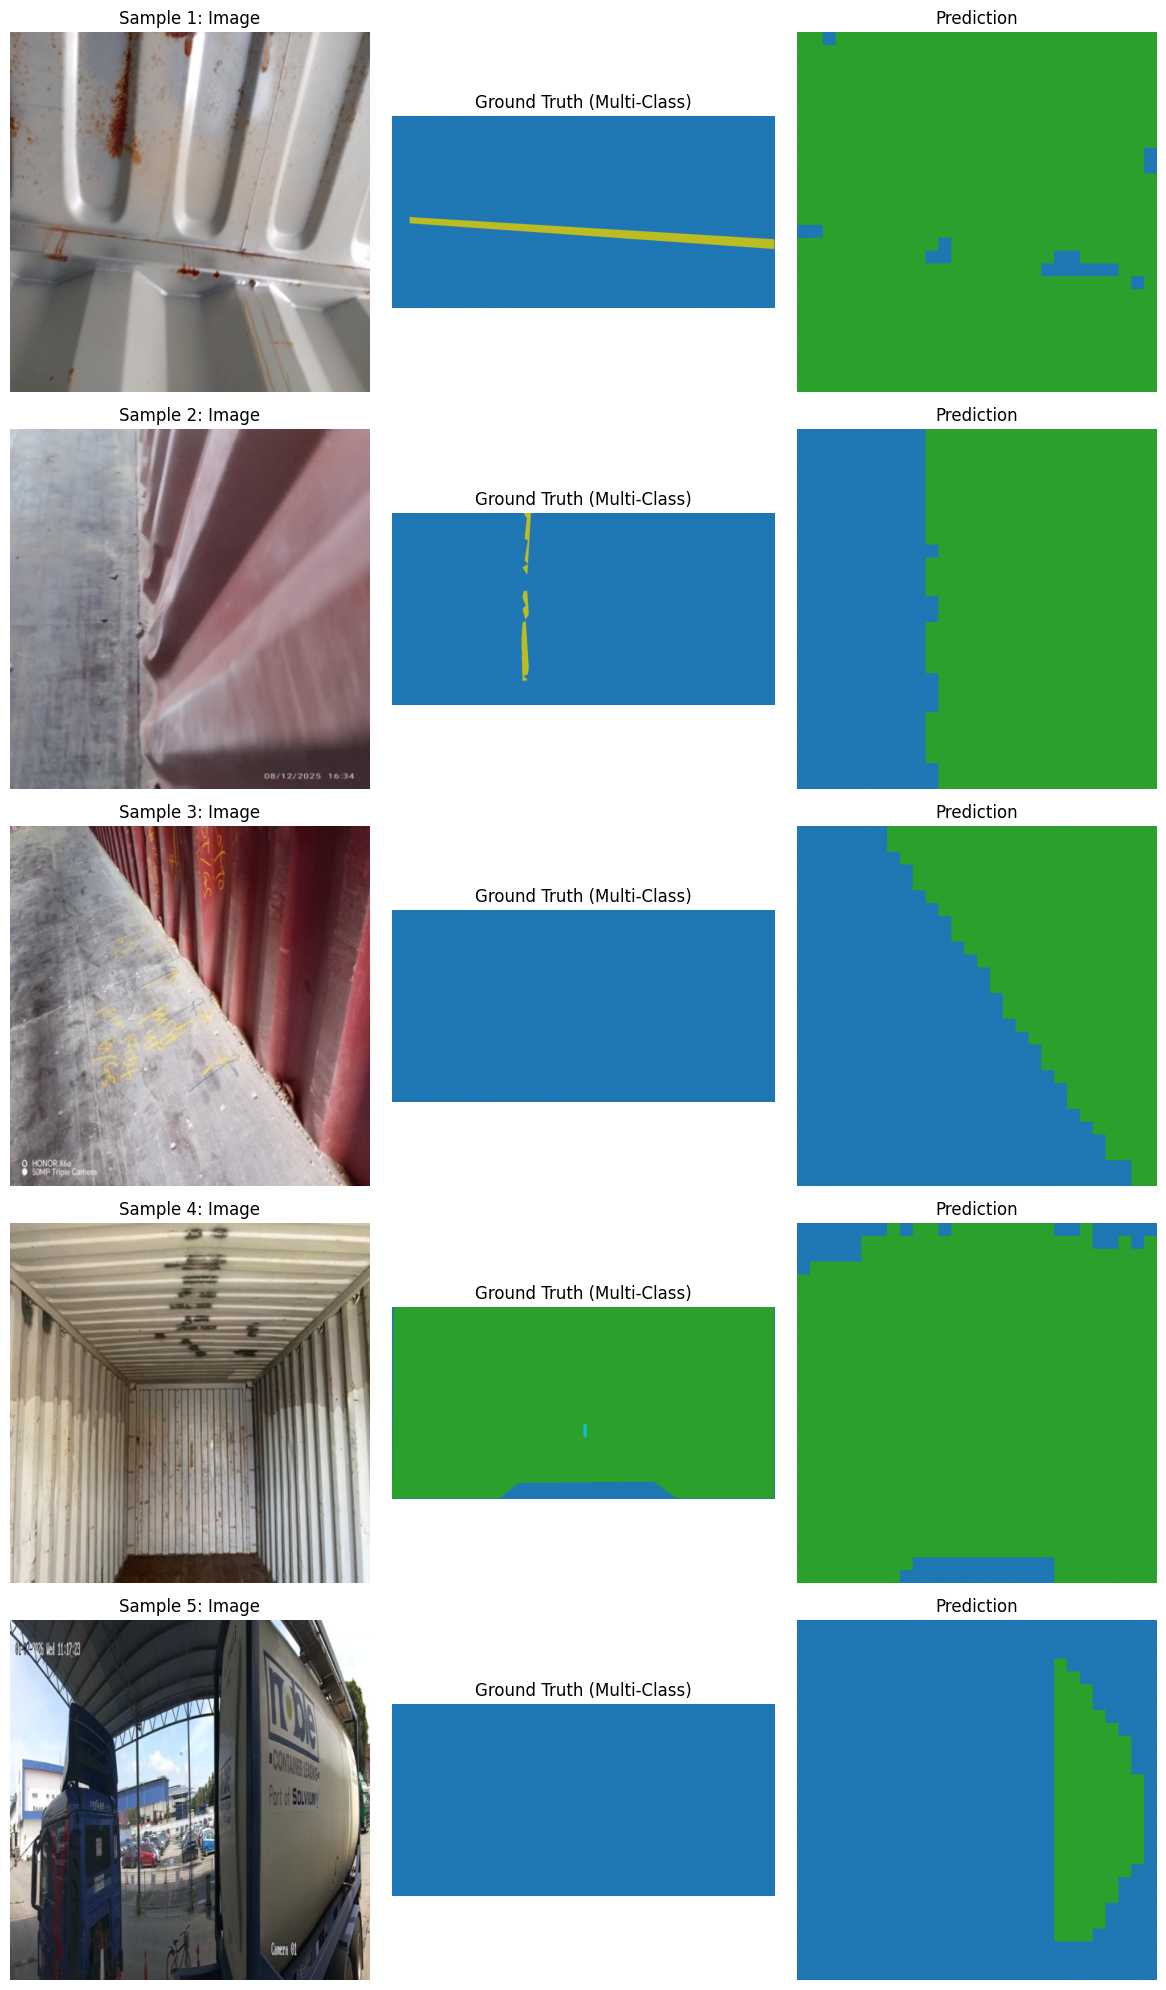

In [15]:
# @title 14. Batch Inference Demo
import random
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

print("Running multi-class batch inference on 5 random samples...")

fig, axes = plt.subplots(5, 3, figsize=(12, 20))

# Use a discrete colormap suitable for 6 distinct classes
cmap = plt.cm.get_cmap('tab10', 6)

for i in range(5):
    # Get random sample
    idx = random.randint(0, len(full_test) - 1)
    img_pil, mask = full_test[idx]

    # Convert for display
    img_display = img_pil.permute(1, 2, 0).numpy()
    img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_display = np.clip(img_display, 0, 1)

    # Get prediction
    pred = predict_segmentation(Image.fromarray((img_display * 255).astype(np.uint8)))

    # Plot - use 2D indexing
    axes[i, 0].imshow(img_display)
    axes[i, 0].set_title(f"Sample {i+1}: Image")
    axes[i, 0].axis('off')

    # Remove the > 0 squashing step and apply multi-class colormap
    axes[i, 1].imshow(mask.squeeze().numpy(), cmap=cmap, vmin=0, vmax=5)
    axes[i, 1].set_title("Ground Truth (Multi-Class)")
    axes[i, 1].axis('off')

    # Apply multi-class colormap to predictions
    axes[i, 2].imshow(pred, cmap=cmap, vmin=0, vmax=5)
    axes[i, 2].set_title("Prediction")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()